# Ouroboros3D — Pipeline Notebook

Implementasi paper **"Ouroboros3D: Image-to-3D Generation via 3D-aware Recursive Diffusion"** (CVPR 2025).

Notebook ini hanya berisi **pipeline & visualisasi**. Semua logika ada di:
- `generate_synthetic_dataset.py` — generate data sintetis
- `dataset.py` — data loader
- `model.py` — arsitektur Ouroboros3D
- `train.py` — training loop

## 1. Setup

In [ ]:
# [0] Clone repo supaya semua file .py (dataset.py, model.py, train.py, dll) tersedia di Colab
# Jalankan cell ini PALING AWAL setelah import notebook ke Colab.
import os
REPO = "ouroboros3d-model-simple"
if not os.path.isdir(REPO):
    !git clone https://github.com/Noelsip/ouroboros3d-model-simple.git
%cd {REPO}
!git pull --ff-only
print("\nFile di working dir:")
!ls *.py

In [1]:
!nvidia-smi || echo "No GPU — akan jalan di CPU"

Tue May  5 13:00:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.57                 Driver Version: 581.57         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   48C    P3             12W /   35W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install torch torchvision numpy pillow matplotlib tqdm -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Generate Dataset Sintetis

60 objek × 8 view — masing-masing menghasilkan **RGB + depth + CCM + camera poses**.

In [3]:
!python generate_synthetic_dataset.py

Generating 60 objects x 8 views @ 128x128
Each view: RGB + depth + CCM + camera pose

Dataset (v2 dengan CCM + poses) tersimpan di: data/synthetic/



Rendering: 100%|██████████| 60/60 [00:10<00:00,  5.95it/s]


## 2b. Pakai Dataset Sendiri dari Google Drive

Dataset-ku: tiap objek punya beberapa gambar **multi-view PNG saja** (tanpa CCM / camera pose).
Langkah:
1. **Download** folder Drive pakai `gdown`.
2. **Konversi** ke format loader (`prepare_real_data.py`): generate `camera_poses.npy` (asumsi turntable, azimuth merata) + CCM placeholder (nol -> loss CCM non-aktif).
3. **Training** pakai `--data-root data/real --w-ccm 0`.

> Catatan: tanpa CCM/pose ground-truth, geometri 3D tidak disupervisi penuh - model tetap belajar generasi RGB multi-view. Kalau urutan view-mu bukan keliling merata 0-360 derajat, sesuaikan `--total-azimuth`.

In [ ]:
# [1] Download folder dataset dari Google Drive
# Folder: https://drive.google.com/drive/folders/1NHl9gv7x9eDbLeL2G8Wpsr6oHNtavopK
!pip install -q gdown
!gdown --folder "https://drive.google.com/drive/folders/1NHl9gv7x9eDbLeL2G8Wpsr6oHNtavopK" -O data/drive_download --remaining-ok

# Cek hasil download
import os
root = "data/drive_download"
print("Isi folder:")
for d in sorted(os.listdir(root))[:10]:
    p = os.path.join(root, d)
    if os.path.isdir(p):
        print(f"  {d}/  ({len(os.listdir(p))} item)")
    else:
        print(f"  {d}")

In [ ]:
# [2] Konversi ke format loader (buat camera_poses + CCM placeholder)
# Kalau jumlah view per objek tidak sama, script otomatis pakai minimum.
# Atur --num-views kalau mau paksa nilai tertentu, --total-azimuth kalau bukan keliling penuh.
!python prepare_real_data.py --input data/drive_download --output data/real

In [ ]:
# [3] Sanity check loader + preview dataset real
import glob
from PIL import Image
import matplotlib.pyplot as plt
from dataset import build_dataloaders

# deteksi num_views dari objek pertama
n_views = len(glob.glob("data/real/object_000/views/view_*.png"))
print(f"num_views terdeteksi: {n_views}")

tr, va = build_dataloaders("data/real", img_size=64, num_views=n_views,
                           batch_size=2, num_workers=0)
print(f"Train batches: {len(tr)} | Val batches: {len(va)}")

# preview objek pertama
fig, axes = plt.subplots(1, n_views, figsize=(2*n_views, 2.4))
axes = [axes] if n_views == 1 else axes
for i in range(n_views):
    axes[i].imshow(Image.open(f"data/real/object_000/views/view_{i:02d}.png"))
    axes[i].set_title(f"view {i}", fontsize=8); axes[i].axis("off")
plt.suptitle("Dataset Real - object_000", y=1.02); plt.tight_layout(); plt.show()

In [ ]:
# [4] Training pakai dataset real
# --w-ccm 0   : matikan loss CCM (tidak ada geometri GT, CCM placeholder nol)
# --w-mask 0.5: aktifkan loss siluet (alpha vs mask foreground) -> bentuk 3D tersupervisi
# Sesuaikan --num-views dengan output cell [3] kalau bukan 8.
!python train.py --data-root data/real --num-views 8 --epochs 10 --batch-size 4 \
    --img-size 64 --num-gaussians 128 --use-feedback --joint --w-ccm 0 --w-mask 0.5 --tag real

## 3. Preview Dataset

Visualisasi RGB, depth map, dan CCM (Canonical Coordinates Map) dari salah satu objek.

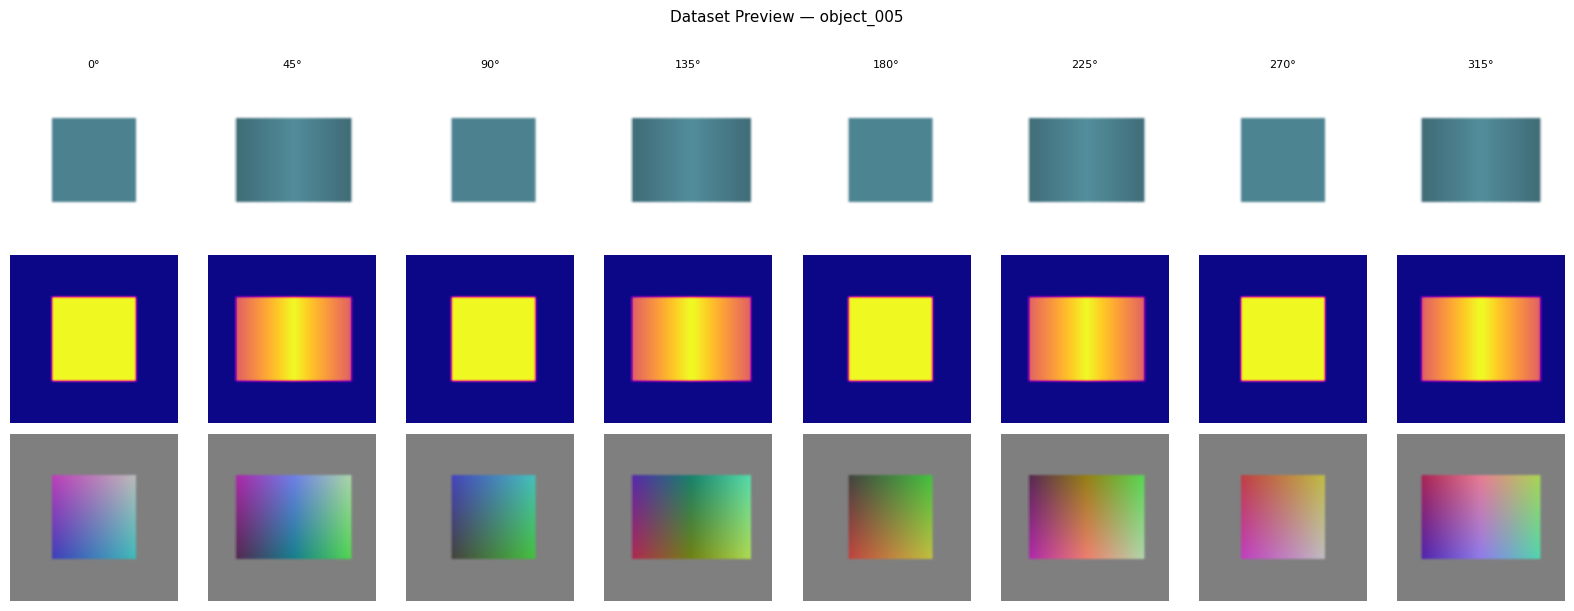

In [4]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

obj_dir = "data/synthetic/object_005"

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
row_labels = ["RGB", "Depth", "CCM (XYZ→RGB)"]

for i in range(8):
    rgb = Image.open(f"{obj_dir}/views/view_{i:02d}.png")
    depth = np.load(f"{obj_dir}/depth/view_{i:02d}.npy")
    ccm = np.load(f"{obj_dir}/ccm/view_{i:02d}.npy")
    ccm_disp = (ccm * 0.5 + 0.5).clip(0, 1)

    axes[0, i].imshow(rgb)
    axes[0, i].set_title(f"{i*45}°", fontsize=8)
    axes[1, i].imshow(depth, cmap="plasma")
    axes[2, i].imshow(ccm_disp)
    for row in range(3):
        axes[row, i].axis("off")

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9)

plt.suptitle("Dataset Preview — object_005", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 4. Sanity Check Data Loader

In [5]:
import torch
import sys
sys.path.insert(0, ".")

from dataset import build_dataloaders

train_loader, val_loader = build_dataloaders(
    root_dir="data/synthetic", batch_size=4, num_workers=0
)
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

batch = next(iter(train_loader))
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k:15s}: {tuple(v.shape)}  range=[{v.min():.3f}, {v.max():.3f}]")

Train batches : 12
Val batches   : 3


c:\MyFolder\ProjekTipis\ouroboros3d_model\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  cond_image     : (4, 3, 128, 128)  range=[-0.671, 1.000]
  target_rgb     : (4, 7, 3, 128, 128)  range=[-0.655, 1.000]
  target_ccm     : (4, 7, 3, 128, 128)  range=[-0.851, 0.851]
  target_mask    : (4, 7, 1, 128, 128)  range=[0.000, 1.000]
  all_rgb        : (4, 8, 3, 128, 128)  range=[-0.671, 1.000]
  all_ccm        : (4, 8, 3, 128, 128)  range=[-0.851, 0.851]
  all_mask       : (4, 8, 1, 128, 128)  range=[0.000, 1.000]
  poses          : (4, 8, 4, 4)  range=[-2.000, 2.000]


## 5. Sanity Check Model

In [6]:
from model import Ouroboros3D

model_check = Ouroboros3D(num_views=8, base_ch=32, num_gaussians=256, img_size=128)
n = model_check.count_parameters()
print(f"Total parameter: {n:,} ({n/1e6:.2f}M)")
print(f"  mv_generator : {sum(p.numel() for p in model_check.mv_generator.parameters())/1e6:.2f}M")
print(f"  reconstructor: {sum(p.numel() for p in model_check.reconstructor.parameters())/1e6:.2f}M")

B, N = 1, 8
cond_dummy = torch.randn(B, 3, 128, 128)
poses_dummy = torch.eye(4).reshape(1, 1, 4, 4).repeat(B, N, 1, 1)
for n_i in range(N):
    a = torch.deg2rad(torch.tensor(n_i * 45.0))
    poses_dummy[:, n_i, 0, 3] = 2.0 * torch.sin(a)
    poses_dummy[:, n_i, 2, 3] = 2.0 * torch.cos(a)

with torch.no_grad():
    outs_dummy = model_check(cond_dummy, poses_dummy, num_recursive_steps=1)
o = outs_dummy[0]
print(f"  pred_target  : {tuple(o['pred_target'].shape)}")
print(f"  rendered_rgb : {tuple(o['rendered_rgb'].shape)}")
print(f"  gaussians.pos: {tuple(o['gaussians']['pos'].shape)}")
print("\n✅ Model OK")
del model_check

Total parameter: 8,064,803 (8.06M)
  mv_generator : 4.26M
  reconstructor: 3.81M
  pred_target  : (1, 7, 3, 128, 128)
  rendered_rgb : (1, 8, 3, 128, 128)
  gaussians.pos: (1, 256, 3)

✅ Model OK


## 6. Training

**Full Ouroboros3D** — joint training + 3D-aware feedback sesuai paper.

In [ ]:
!python train.py --epochs 10 --batch-size 4 --img-size 128 --num-gaussians 128 --use-feedback --joint --tag full

## 7. Loss Curve

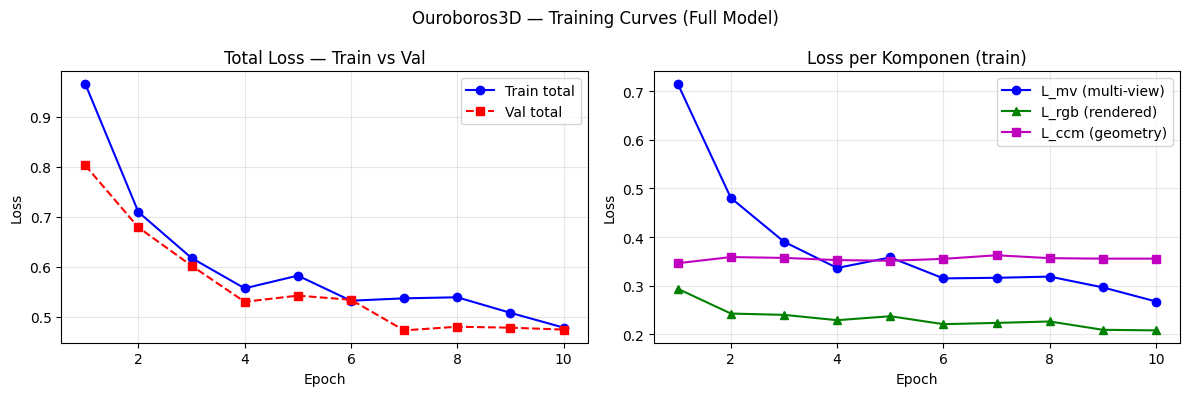

Loss epoch-1: 0.9663  →  epoch-10: 0.4780  (50.5% turun)


In [9]:
import torch
import matplotlib.pyplot as plt

ckpt = torch.load("checkpoints/ouroboros_full.pt", map_location="cpu", weights_only=False)
history = ckpt["history"]

epochs    = [h["epoch"]           for h in history]
train_tot = [h["train"]["total"]  for h in history]
val_tot   = [h["val"]["total"]    for h in history]
train_mv  = [h["train"]["mv"]     for h in history]
train_rnd = [h["train"]["render"] for h in history]
train_ccm = [h["train"]["ccm"]    for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_tot, "b-o", label="Train total")
ax1.plot(epochs, val_tot,   "r--s", label="Val total")
ax1.set_title("Total Loss — Train vs Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_mv,  "b-o",  label="L_mv (multi-view)")
ax2.plot(epochs, train_rnd, "g-^",  label="L_rgb (rendered)")
ax2.plot(epochs, train_ccm, "m-s",  label="L_ccm (geometry)")
ax2.set_title("Loss per Komponen (train)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("Ouroboros3D — Training Curves (Full Model)", fontsize=12)
plt.tight_layout()
plt.show()

delta = (train_tot[0] - train_tot[-1]) / train_tot[0] * 100
print(f"Loss epoch-1: {train_tot[0]:.4f}  →  epoch-{epochs[-1]}: {train_tot[-1]:.4f}  ({delta:.1f}% turun)")

## 8. Ablation Study (opsional)

Reproduksi Tabel 2 paper — efek joint training dan feedback.

In [18]:
!python train.py --epochs 10 --batch-size 4 --img-size 64 --num-gaussians 128 --tag baseline

Device: cpu
Config: use_feedback=False, joint=False, tag=baseline

[1/4] Dataloaders...
  train=12 batch, val=3 batch

[2/4] Building Ouroboros3D model...
  params: 6,656,099 (6.66M)
    - mv_generator : 3.37M
    - reconstructor: 3.28M

[3/4] Training for 10 epoch(s)...
Epoch 1/10 | train: mv=0.555 rnd=0.000 ccm=0.000 tot=0.555 | val: mv=0.410 rnd=0.000 ccm=0.000 tot=0.410 | 15.9s
Epoch 2/10 | train: mv=0.363 rnd=0.000 ccm=0.000 tot=0.363 | val: mv=0.347 rnd=0.000 ccm=0.000 tot=0.347 | 33.8s
Epoch 3/10 | train: mv=0.303 rnd=0.000 ccm=0.000 tot=0.303 | val: mv=0.288 rnd=0.000 ccm=0.000 tot=0.288 | 51.3s
Epoch 4/10 | train: mv=0.281 rnd=0.000 ccm=0.000 tot=0.281 | val: mv=0.265 rnd=0.000 ccm=0.000 tot=0.265 | 75.2s
Epoch 5/10 | train: mv=0.246 rnd=0.000 ccm=0.000 tot=0.246 | val: mv=0.281 rnd=0.000 ccm=0.000 tot=0.281 | 91.1s
Epoch 6/10 | train: mv=0.228 rnd=0.000 ccm=0.000 tot=0.228 | val: mv=0.251 rnd=0.000 ccm=0.000 tot=0.251 | 109.5s
Epoch 7/10 | train: mv=0.211 rnd=0.000 ccm=0.000 


[Ep 1] train:   0%|          | 0/12 [00:00<?, ?it/s]c:\MyFolder\ProjekTipis\ouroboros3d_model\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

[Ep 1] train: 100%|██████████| 12/12 [00:14<00:00,  1.05s/it, ccm=0.000, mv=0.436, rnd=0.000, tot=0.436]
                                                                                                        

[Ep 1] val  : 100%|██████████| 3/3 [00:01<00:00,  2.19it/s]
                                                           

[Ep 2] train: 100%|██████████| 12/12 [00:15<00:00,  1.25s/it, ccm=0.000, mv=0.450, rnd=0.000, tot=0.450]
                                                                                                        

[Ep 2] val  : 100%|██████████| 3/3 [00:01<00:00,  1.79it/s]
                                                           

[Ep 3] train: 100%|██████████| 12

In [11]:
!python train.py --epochs 10 --batch-size 4 --img-size 64 --num-gaussians 128 --joint --tag joint_only

Device: cpu
Config: use_feedback=False, joint=True, tag=joint_only

[1/4] Dataloaders...
  train=12 batch, val=3 batch

[2/4] Building Ouroboros3D model...
  params: 6,656,099 (6.66M)
    - mv_generator : 3.37M
    - reconstructor: 3.28M

[3/4] Training for 10 epoch(s)...
Epoch 1/10 | train: mv=0.626 rnd=0.291 ccm=0.340 tot=0.874 | val: mv=0.460 rnd=0.230 ccm=0.355 tot=0.682 | 24.6s
Epoch 2/10 | train: mv=0.384 rnd=0.238 ccm=0.361 tot=0.611 | val: mv=0.345 rnd=0.210 ccm=0.351 tot=0.555 | 45.3s
Epoch 3/10 | train: mv=0.299 rnd=0.213 ccm=0.351 tot=0.511 | val: mv=0.269 rnd=0.204 ccm=0.350 tot=0.477 | 66.7s
Epoch 4/10 | train: mv=0.273 rnd=0.213 ccm=0.365 tot=0.489 | val: mv=0.297 rnd=0.208 ccm=0.364 tot=0.510 | 84.4s
Epoch 5/10 | train: mv=0.261 rnd=0.216 ccm=0.361 tot=0.477 | val: mv=0.241 rnd=0.206 ccm=0.353 tot=0.450 | 102.8s
Epoch 6/10 | train: mv=0.229 rnd=0.201 ccm=0.353 tot=0.435 | val: mv=0.223 rnd=0.195 ccm=0.363 tot=0.429 | 119.4s
Epoch 7/10 | train: mv=0.216 rnd=0.192 ccm=0.34


[Ep 1] train:   0%|          | 0/12 [00:00<?, ?it/s]c:\MyFolder\ProjekTipis\ouroboros3d_model\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

[Ep 1] train: 100%|██████████| 12/12 [00:23<00:00,  1.74s/it, ccm=0.379, mv=0.456, rnd=0.268, tot=0.704]
                                                                                                        

[Ep 1] val  : 100%|██████████| 3/3 [00:01<00:00,  2.29it/s]
                                                           

[Ep 2] train: 100%|██████████| 12/12 [00:19<00:00,  1.65s/it, ccm=0.400, mv=0.372, rnd=0.256, tot=0.620]
                                                                                                        

[Ep 2] val  : 100%|██████████| 3/3 [00:01<00:00,  2.23it/s]
                                                           

[Ep 3] train: 100%|██████████| 12

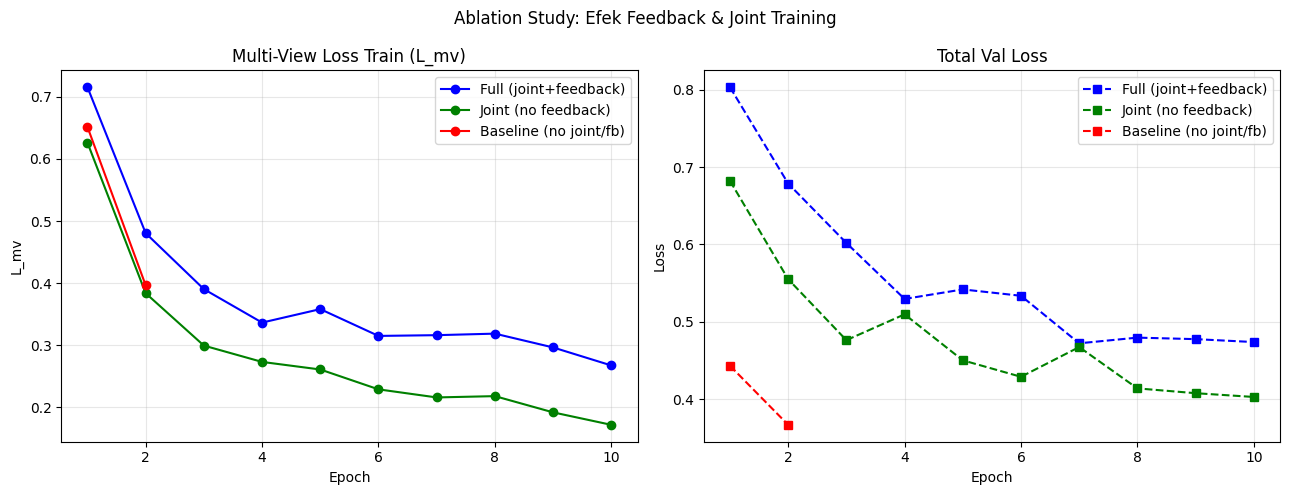

In [12]:
import os
import torch
import matplotlib.pyplot as plt

configs = [
    ("full",       "Full (joint+feedback)",  "blue"),
    ("joint_only", "Joint (no feedback)",    "green"),
    ("baseline",   "Baseline (no joint/fb)", "red"),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for tag, label, color in configs:
    path = f"checkpoints/ouroboros_{tag}.pt"
    if not os.path.exists(path):
        print(f"  [skip] {path} tidak ditemukan")
        continue
    h = torch.load(path, map_location="cpu", weights_only=False)["history"]
    eps   = [x["epoch"] for x in h]
    tr_mv = [x["train"]["mv"]    for x in h]
    va_to = [x["val"]["total"]   for x in h]
    ax1.plot(eps, tr_mv, color=color, marker="o", label=label)
    ax2.plot(eps, va_to, color=color, marker="s", linestyle="--", label=label)

for ax, title, yl in [(ax1, "Multi-View Loss Train (L_mv)", "L_mv"),
                       (ax2, "Total Val Loss", "Loss")]:
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(yl)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Ablation Study: Efek Feedback & Joint Training", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Visualisasi Hasil Prediksi

Load checkpoint full model, jalankan inference, tampilkan GT / prediksi / rendered 3DGS / CCM.

In [13]:
import torch
from dataset import build_dataloaders
from model import Ouroboros3D

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load("checkpoints/ouroboros_full.pt", map_location=device, weights_only=False)
model = Ouroboros3D(
    num_views=8, base_ch=32, num_gaussians=128, img_size=64, use_feedback=True
).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()

_, val_loader = build_dataloaders("data/synthetic", img_size=64, batch_size=1, num_workers=0)
batch = next(iter(val_loader))
cond  = batch["cond_image"].to(device)
poses = batch["poses"].to(device)

with torch.no_grad():
    outs = model(cond, poses, num_recursive_steps=1)

print("Model loaded & inference selesai.")

Model loaded & inference selesai.


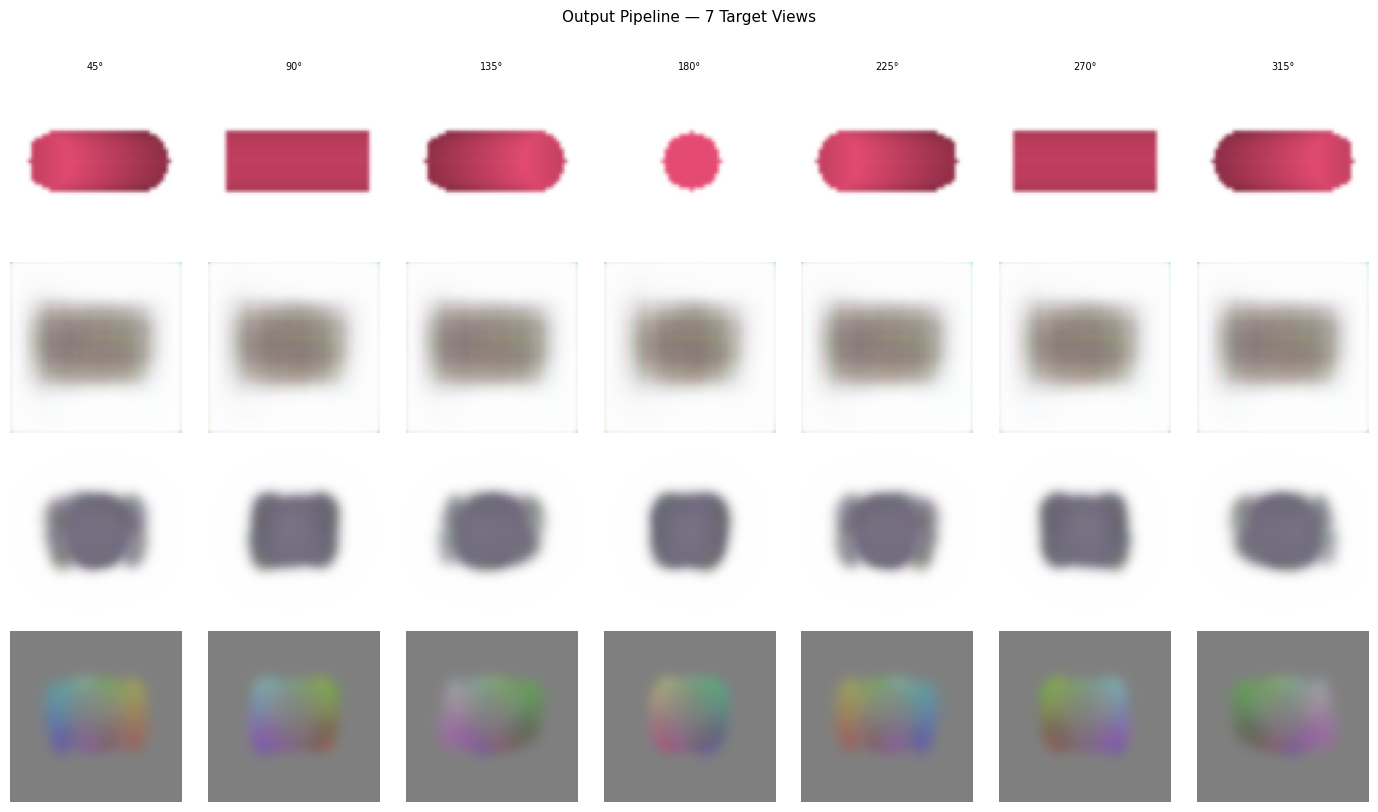

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def denorm(t):
    return (t.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)

pred = outs[0]["pred_target"][0].cpu()   # [7, 3, 64, 64]
gt   = batch["target_rgb"][0]             # [7, 3, 64, 64]
rend = outs[0]["rendered_rgb"][0].cpu()  # [8, 3, 64, 64]
ccm  = outs[0]["rendered_ccm"][0].cpu()  # [8, 3, 64, 64]

n_views = pred.shape[0]  # 7
row_labels = ["Ground Truth", "Pred (MultiViewGen)", "Rendered 3DGS", "CCM (Geo)"]

fig, axes = plt.subplots(4, n_views, figsize=(14, 8))
for i in range(n_views):
    axes[0, i].imshow(denorm(gt[i]))
    axes[0, i].set_title(f"{(i+1)*45}°", fontsize=7)
    axes[1, i].imshow(denorm(pred[i]))
    axes[2, i].imshow(denorm(rend[i + 1]))
    ccm_disp = (ccm[i + 1].permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
    axes[3, i].imshow(ccm_disp)
    for row in range(4):
        axes[row, i].axis("off")

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=8)

plt.suptitle("Output Pipeline — 7 Target Views", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 10. Analisis 3D Gaussians

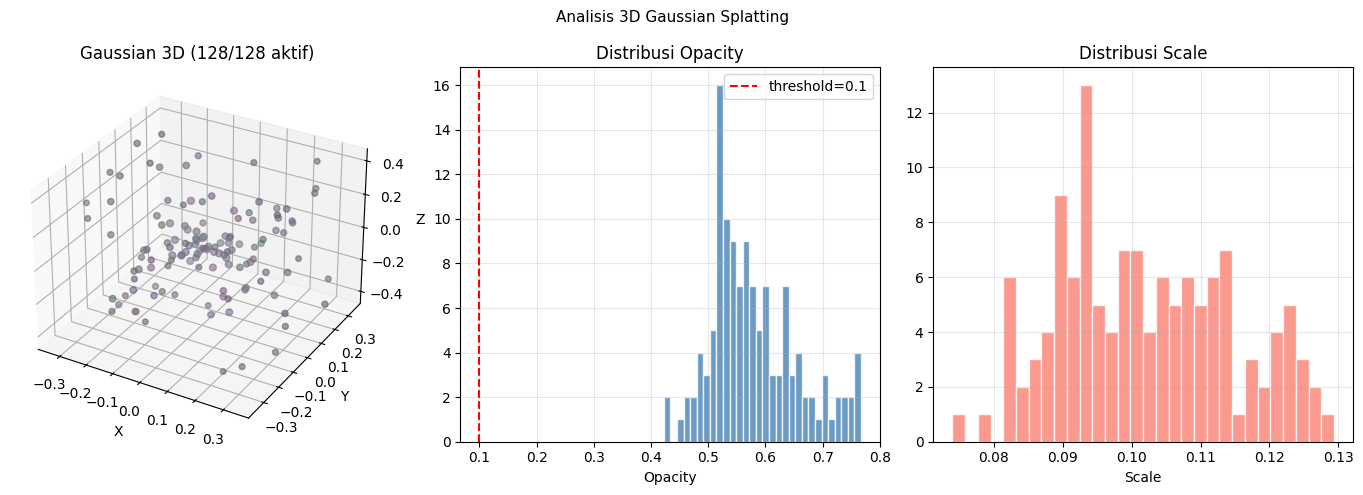

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

gaussians = outs[0]["gaussians"]
pos   = gaussians["pos"][0].cpu().numpy()          # [K, 3]
rgb   = gaussians["rgb"][0].cpu().numpy()          # [K, 3]
opa   = gaussians["opacity"][0, :, 0].cpu().numpy() # [K]
scale = gaussians["scale"][0, :, 0].cpu().numpy()   # [K]

mask = opa > 0.1

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(131, projection="3d")
ax1.scatter(pos[mask, 0], pos[mask, 1], pos[mask, 2],
            c=rgb[mask], s=scale[mask] * 200, alpha=0.6)
ax1.set_title(f"Gaussian 3D ({mask.sum()}/{len(mask)} aktif)")
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")

ax2 = fig.add_subplot(132)
ax2.hist(opa, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
ax2.axvline(0.1, color="red", linestyle="--", label="threshold=0.1")
ax2.set_title("Distribusi Opacity"); ax2.set_xlabel("Opacity")
ax2.legend(); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(133)
ax3.hist(scale, bins=30, color="salmon", edgecolor="white", alpha=0.8)
ax3.set_title("Distribusi Scale"); ax3.set_xlabel("Scale")
ax3.grid(True, alpha=0.3)

plt.suptitle("Analisis 3D Gaussian Splatting", fontsize=11)
plt.tight_layout()
plt.show()

## 11. Recursive Feedback — Step 1 vs Step 2

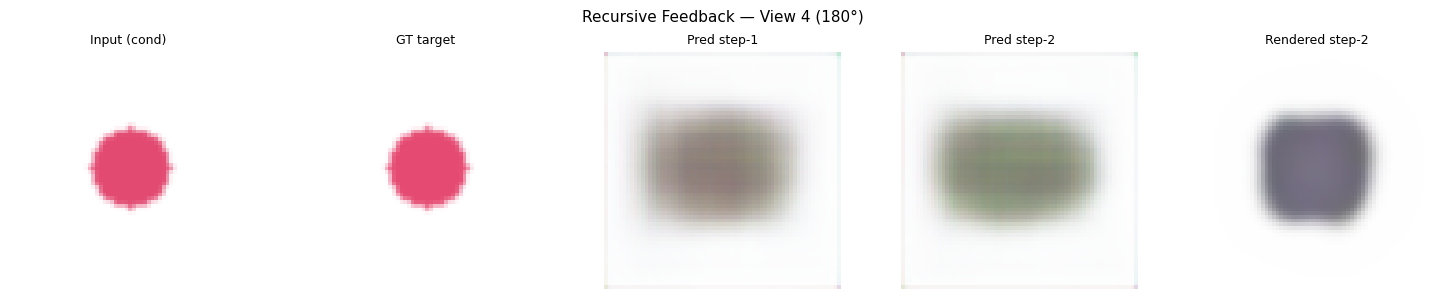

L1 vs GT  —  Step-1: 0.1998  |  Step-2: 0.2160
ℹ️  Step-1 & step-2 comparable (model belum converged penuh)


In [16]:
import matplotlib.pyplot as plt

with torch.no_grad():
    outs_2 = model(cond, poses, num_recursive_steps=2)

view_idx = 3  # 135°

cond_img   = batch["cond_image"][0]
gt_view    = batch["target_rgb"][0, view_idx]
pred_s1    = outs[0]["pred_target"][0, view_idx].cpu()
pred_s2    = outs_2[-1]["pred_target"][0, view_idx].cpu()
rend_s2    = outs_2[-1]["rendered_rgb"][0, view_idx + 1].cpu()

def denorm(t):
    return (t.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, img, title in zip(axes,
    [cond_img, gt_view, pred_s1, pred_s2, rend_s2],
    ["Input (cond)", "GT target", "Pred step-1", "Pred step-2", "Rendered step-2"]):
    ax.imshow(denorm(img))
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle(f"Recursive Feedback — View {view_idx+1} ({(view_idx+1)*45}°)", fontsize=11)
plt.tight_layout()
plt.show()

l1_s1 = (pred_s1 - gt_view).abs().mean().item()
l1_s2 = (pred_s2 - gt_view).abs().mean().item()
print(f"L1 vs GT  —  Step-1: {l1_s1:.4f}  |  Step-2: {l1_s2:.4f}")
if l1_s2 < l1_s1:
    print(f"✅ Step-2 lebih baik: {(l1_s1-l1_s2)/l1_s1*100:.1f}% improvement")
else:
    print("ℹ️  Step-1 & step-2 comparable (model belum converged penuh)")

## 12. Ringkasan Pipeline & Metrik

In [17]:
import numpy as np
import torch

print("=" * 65)
print("  PIPELINE OUROBOROS3D")
print("=" * 65)
print("""
  Input Image (1 view)
       │
       ▼
  [F_θ] MultiViewGenerator  ◄── RGB + CCM feedback (step ≥ 2)
       │  Output: 7 predicted target views
       ▼
  [G] GaussianPredictor
       │  multi-view RGB → K Gaussian primitives (pos+rgb+opa+scale)
       ▼
  [R] GaussianRenderer
       │  differentiable splatting → rendered RGB + CCM per view
       └──► feedback ke F_θ (recursive loop)
""")
print("=" * 65)

with torch.no_grad():
    outs_eval = model(cond, poses, num_recursive_steps=1)

pred_all = outs_eval[0]["pred_target"][0].cpu()
gt_all   = batch["target_rgb"][0]
mse  = ((pred_all * 0.5 + 0.5) - (gt_all * 0.5 + 0.5)).pow(2).mean().item()
psnr = 10 * np.log10(1.0 / (mse + 1e-8))
l1   = (pred_all - gt_all).abs().mean().item()
n_params = model.count_parameters()

print(f"  Model parameters : {n_params:,} ({n_params/1e6:.2f}M)")
print(f"  Val L1 loss      : {l1:.4f}")
print(f"  Val PSNR (approx): {psnr:.2f} dB")
print(f"  Gaussian count   : {outs_eval[0]['gaussians']['pos'].shape[1]}")
print("=" * 65)
print("\n✅ Pipeline selesai end-to-end!")

  PIPELINE OUROBOROS3D

  Input Image (1 view)
       │
       ▼
  [F_θ] MultiViewGenerator  ◄── RGB + CCM feedback (step ≥ 2)
       │  Output: 7 predicted target views
       ▼
  [G] GaussianPredictor
       │  multi-view RGB → K Gaussian primitives (pos+rgb+opa+scale)
       ▼
  [R] GaussianRenderer
       │  differentiable splatting → rendered RGB + CCM per view
       └──► feedback ke F_θ (recursive loop)

  Model parameters : 7,453,475 (7.45M)
  Val L1 loss      : 0.2052
  Val PSNR (approx): 15.46 dB
  Gaussian count   : 128

✅ Pipeline selesai end-to-end!
